In [5]:
#@title Run this cell to setup visualization...
# This cell defines plot_progress() which plots an optimization trace.

import matplotlib
from matplotlib import pyplot as plt

def plot_progress(bowl, track, losses):
    # Draw the contours of the objective function, and x, and y
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12, 5))
    for size in torch.linspace(0.1, 1.0, 10):
        angle = torch.linspace(0, 6.3, 100)
        circle = torch.stack([angle.sin(), angle.cos()])
        ellipse = torch.mm(torch.inverse(bowl), circle) * size
        ax1.plot(ellipse[0,:], ellipse[1,:], color='skyblue')
    track = torch.stack(track).t()
    ax1.set_title('progress of x')
    ax1.plot(track[0,:], track[1,:], marker='o')
    ax1.set_ylim(-1, 1)
    ax1.set_xlim(-1.6, 1.6)
    ax1.set_ylabel('x[1]')
    ax1.set_xlabel('x[0]')
    ax2.set_title('progress of y')
    ax2.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))
    ax2.plot(range(len(losses)), losses, marker='o')
    ax2.set_ylabel('objective')
    ax2.set_xlabel('iteration')
    fig.show()

from IPython.display import HTML
HTML('''<script>function toggle_code(){$('.rendered.selected div.input').toggle().find('textarea').focus();} $(toggle_code())</script>
<a href="javascript:toggle_code()">Toggle</a> the code for plot_progress.''')

Pytorch Optimizers
==================

Optimizers have a simple job: given gradients of an objective with respect to a set of input parameters, adjust the parameters reduce the objective.  They do this by modifying each parameter by a small amount in the direction given by the gradient.


Gradient descent just subtracts the gradient
---------
You can apply gradient descent by hand easily by just using `loss.backward()` to compute the gradient of the loss with respect to every parameter `x`, and then apply `x -= learning_rate * x.grad` to nudge `x` in the gradient direction that makes the loss smaller.

Here is an example of applying gradient descent by hand:

tensor([ 1.1459, -2.4894])


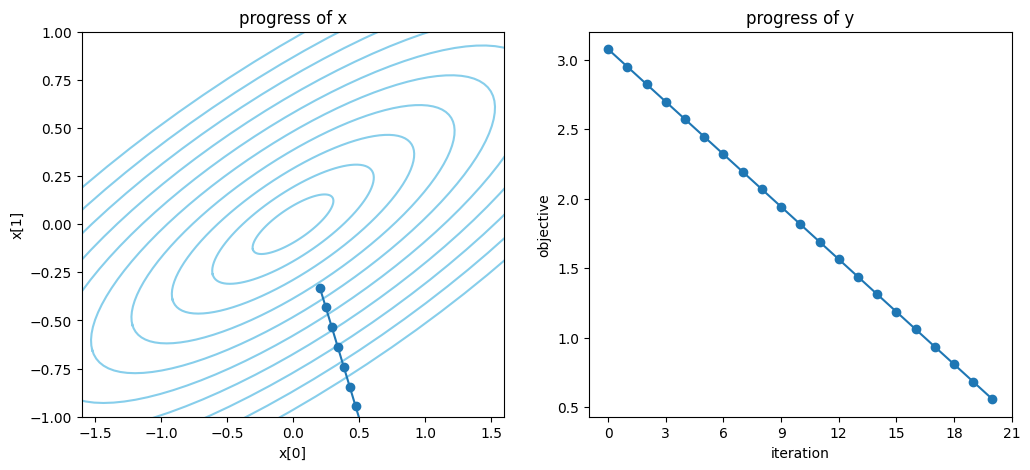

In [6]:
import torch

x_init = torch.randn(2)
x = x_init.clone()
print(x)

bowl = torch.tensor([[ 0.4410, -1.0317], [-0.2844, -0.1035]])
track, losses = [], []

for iter in range(21):
    x.requires_grad = True
    loss = torch.mm(bowl, x[:,None]).norm()
    loss.backward()
    with torch.no_grad(): # to avoid recomputing the gradient, its already calculated
                              # as part of the .backward()
        x = x - 0.1 * x.grad
    track.append(x.detach().clone())
    losses.append(loss.detach())

plot_progress(bowl, track, losses)

Built-in optimization algorithms
------

Pytorch includes several optimization algorithms.

The actual optmization algorithms employ a number of techniques to make the process faster and more robust as repeated steps are taken, by trying to adapt to the shape of the objective surface as it is explored.  The simplest method is SGD-with-momentum, which is implemented in pytorch as `pytorch.optim.SGD`.

Using SGD
---------

To use SGD, you need to calculate your objective and fill in gradients on all the parameters before it can take a step.

  1. Set your parameters (x in this case) to `x.requires_grad = True` so autograd tracks them (line 5).
  2. Create the optimizer and tell it about the parameters to adjust (`[x]` here) (line 6).
  3. In a loop, compute your objective, then call `loss.backward()` to fill in `x.grad` and then `optimizer.step()` to adjust `x` accordingly (lines 12-15).
  
**Remember to zero gradient.** Notice that we use `optimizer.zero_grad()` each time to set x.grad to zero before recomputing gradients; if we do not do this, then the new gradient will be added to the old one.


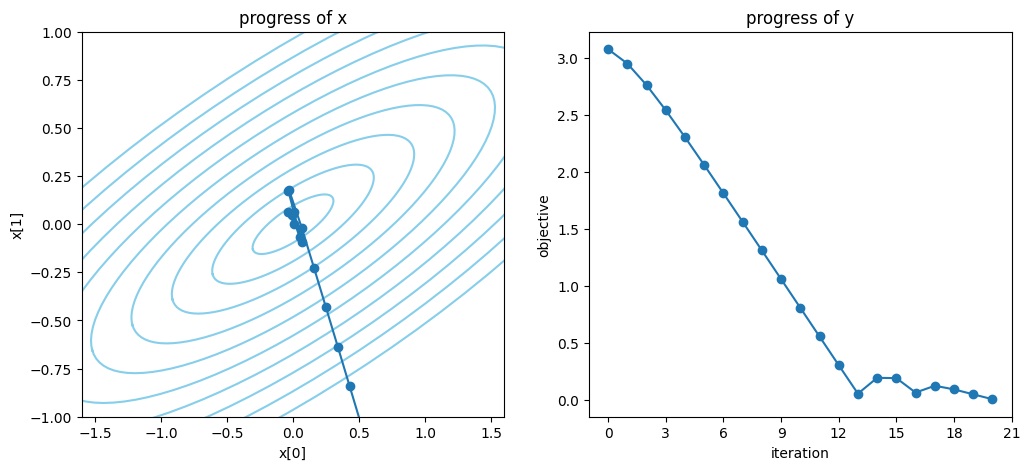

In [7]:
import torch

x = x_init.clone()
x.requires_grad = True
optimizer = torch.optim.SGD([x], lr=0.1, momentum=0.5)

bowl = torch.tensor([[ 0.4410, -1.0317], [-0.2844, -0.1035]])
track, losses = [], []

for iter in range(21):
    loss = torch.mm(bowl, x[:,None]).norm()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    track.append(x.detach().clone())
    losses.append(loss.detach())

plot_progress(bowl, track, losses)

### Exercise

1. Set the `x_init` fixed, to the point `torch.tensor([-1.0, 0.0])`.
2. Increase the number of iterations to 101.
3. Experiment with different combinations of `lr` and `momentum` to see which converges to zero `y` best.

In [8]:
# TODO: Copy the SGD cell above, and modify it to
# 1. set x_init to [-1, 0]
# 2. Increase iterations to 101
# 3. Find settings for lr and momenum that get the lowest objective

Using other optimizers
----------------------

Other optimizers are similar.  Adam is a popular adaptive method that does well without much tuning, and can be dropped in to replace plain SGD.

Some other fancy optimizers, such as LBFGS, need to be given an objective function that they can call repeatedly to probe gradients themselves.  Examples can be found elsewhere: for example [hjmshi's LBFGS includes some examples](https://github.com/hjmshi/PyTorch-LBFGS/blob/master/examples/Other/lbfgs_tests.py#L129-L132).

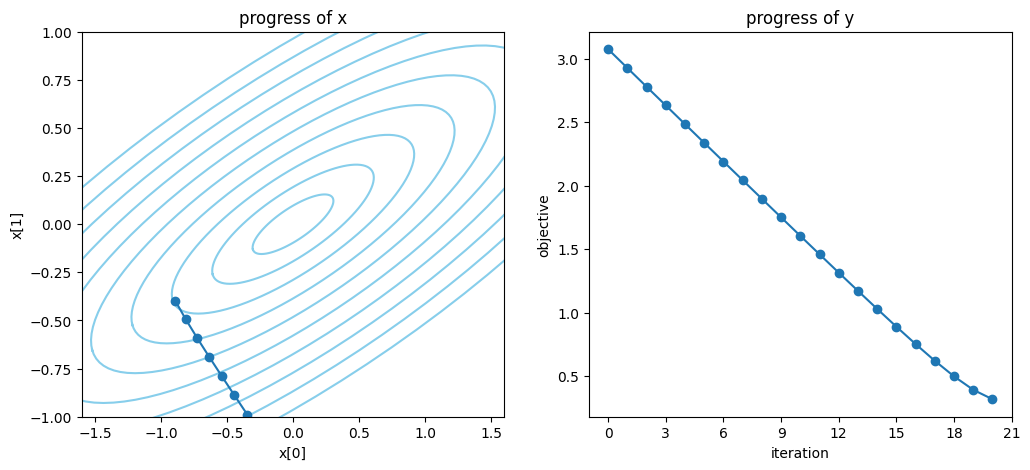

In [9]:
# The code below uses Adam
x = x_init.clone()
x.requires_grad = True
optimizer = torch.optim.Adam([x], lr=0.1)

track, losses = [], []

for iter in range(21):
    loss = torch.mm(bowl, x[:,None]).norm()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    track.append(x.detach().clone())
    losses.append(loss.detach())

plot_progress(bowl, track, losses)

### Exercise

We will try the LBFGS optimizer.

1. To start, as in the first exercise, set `x_init` to `torch.tensor([-1.0, 0.0])` and increase to 101 iterations.
2. Define a zero-argument function for the loss, e.g.: `loss = lambda: torch.mm(bowl, x[:,None]).norm()`
3. Use `torch.optim.LBFGS` as the optimizer, setting the option `max_eval=5`.  Since this optimizer probes the loss several different points for each step, `optimizer.step` requires the `loss` function as an argument now.
4. Experiment with different learning rates and `max_eval` values.

Note that LBFGS is a very memory-intensive optimizer, too expensive for training most neural networks.  But for a small parameter set it is great.



In [10]:
# TODO: Copy the SGD cell above, and modify it to
# 1. set x_init to [-1, 0] and increase iterations to 101
# 2. define a zero-argument `loss` function
# 3. use LBFGS instead of SGD.  Pay attention to the `loss` argument of `optimizer.step()`
# 4. experiment with LBFGS settings.

Other tricks
------------------------

 1. **Learning rate schedules**.  One of the simplest and most effective ways to improve training is to adjust the learning rate, decreasing it during training.   There are many differerent strategies for scheduling learning rates, and pytorch comes with a set of `torch.optim.lr_scheduler` classes to make it easy to drop in a variety of methods.  See [Stack overflow](https://stackoverflow.com/questions/48324152/) or [scheduler documentation](https://pytorch.org/docs/stable/optim.html#torch.optim.lr_scheduler.StepLR).
 2. **Multiple optimizers**. Sometimes you want to optimize more than one objective.  The ordinary solution to this is to make an single overall objective as a (weighted) sum of all the objectives.  However, sometimes you want to apply one objective to some parameters and a different objective to a different set of parameters.  This occurs, for example in *adversarial training* such as in GANs, where two networks are learning to play against each other.  In this case you can use multiple different optimizers, one for each opposing objective.  See [Examples of GAN implementations](https://github.com/eriklindernoren/PyTorch-GAN/blob/master/implementations/gan/gan.py#L112-L113) to see how this is done.

### [On to topic 4: Modules &rightarrow;](4-Pytorch-Modules.ipynb)

### 'Bowl' Concept in a Neural Network Analogy

In this example, we'll demonstrate how the `bowl` matrix can act as a regularization component in a neural network's loss function.

*   **`w`**: These are the learnable parameters (weights) of our simple model, analogous to `x` in the previous example.
*   **`bowl_matrix`**: This is a fixed matrix that defines a quadratic penalty (regularization) on our `w` values. It's not input data, but a characteristic of the loss function itself.
*   **`X_data` and `y_target`**: These represent our 'real' input data and corresponding target output that our model tries to fit.

The total loss will be a combination of a **data-fitting loss** (how well `w` explains `X_data` to predict `y_target`) and a **regularization loss** (the `bowl` term that pushes `w` towards a certain shape).

In [13]:
import torch
import matplotlib.pyplot as plt

# --- 1. Define 'w' (our learnable parameters/weights) ---
# Analogous to 'x' from the original example, but now called 'w' for a clearer neural network context.
w_init = torch.tensor([-0.5, 0.5]) # Initial guess for weights
w = w_init.clone().requires_grad_(True)
print(f"Initial weights (w): {w}")

# --- 2. Define 'bowl_matrix' (fixed quadratic penalty term) ---
# This matrix defines the shape of a regularization component in our loss.
# It's fixed and influences the loss surface, but is not 'input data'.
bowl_matrix = torch.tensor([[ 0.4410, -1.0317], [-0.2844, -0.1035]])

# --- 3. Generate 'Real Input Data' and 'Target' ---
# This is our actual data that the model should try to fit.
# X_data: a 2D input feature vector (e.g., representing two features)
# y_target: the corresponding target output
X_data = torch.tensor([1.0, 1.0]) # Example input features
y_target = torch.tensor(0.5)      # Example target output

print(f"Real input data (X_data): {X_data}")
print(f"Real target data (y_target): {y_target}")

# --- 4. Define the Optimizer ---
optimizer = torch.optim.SGD([w], lr=0.05, momentum=0.9)

# --- 5. Optimization Loop ---
track_w, losses_total, losses_data, losses_bowl = [], [], [], []
num_iterations = 100

for iter_idx in range(num_iterations):
    # --- Model's forward pass ---
    # A simple linear model predicting y_pred from X_data and weights 'w'
    y_pred = torch.dot(w, X_data)

    # --- Data-fitting Loss (e.g., Mean Squared Error) ---
    # How well does our model fit the 'real' input data to the 'real' target?
    loss_data_fit = (y_pred - y_target)**2

    # --- Bowl-shaped Regularization Loss ---
    # This is the 'bowl' term, acting as a penalty on our weights 'w'.
    # It pushes 'w' towards the minimum of the bowl defined by 'bowl_matrix'.
    # We multiply by a small factor (e.g., 0.1) to balance its influence.
    loss_reg_bowl = torch.mm(bowl_matrix, w[:,None]).norm()

    # --- Total Loss ---
    # The optimizer will try to minimize this combined loss.
    total_loss = loss_data_fit + 0.1 * loss_reg_bowl

    # --- Optimization steps ---
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    # --- Record progress for visualization ---
    track_w.append(w.detach().clone()) # Store the weights' path
    losses_total.append(total_loss.detach()) # Store the total loss
    losses_data.append(loss_data_fit.detach()) # Store data-fitting loss
    losses_bowl.append(loss_reg_bowl.detach()) # Store regularization loss

print(f"\nFinal weights (w) after {num_iterations} iterations: {w.detach()}")
print(f"Final total loss: {losses_total[-1]:.4f}")
print(f"Final data fitting loss: {losses_data[-1]:.4f}")
print(f"Final regularization loss: {losses_bowl[-1]:.4f}")

Initial weights (w): tensor([-0.5000,  0.5000], requires_grad=True)
Real input data (X_data): tensor([1., 1.])
Real target data (y_target): 0.5

Final weights (w) after 100 iterations: tensor([0.3344, 0.1566])
Final total loss: 0.0113
Final data fitting loss: 0.0001
Final regularization loss: 0.1121


### Visualization of Combined Loss and Weight Trajectory

Below, we'll plot how the different components of the loss evolve over time, and also visualize the path that our weights `w` take on the contour of the `bowl_matrix` regularization term.

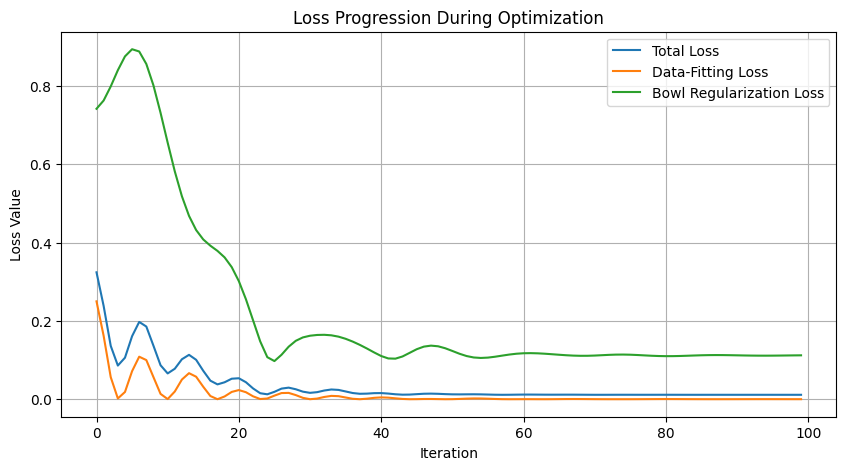

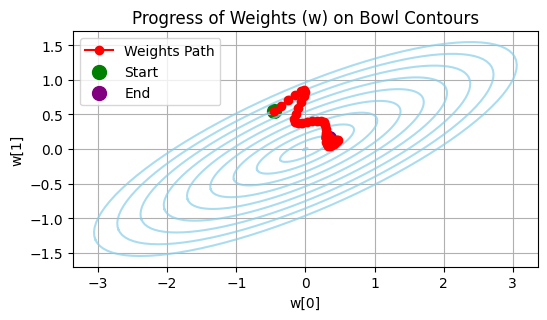

In [14]:
import matplotlib.pyplot as plt

# Plotting the loss progression
plt.figure(figsize=(10, 5))
plt.plot(losses_total, label='Total Loss')
plt.plot(losses_data, label='Data-Fitting Loss')
plt.plot(losses_bowl, label='Bowl Regularization Loss')
plt.title('Loss Progression During Optimization')
plt.xlabel('Iteration')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)
plt.show()

# Plotting the path of 'w' on the 'bowl' contours
def plot_w_progress_on_bowl(bowl_mat, w_track, title="Progress of Weights (w) on Bowl Contours"):
    fig, ax = plt.subplots(figsize=(6, 6))
    # Plot concentric ellipses (contours of the bowl regularization)
    for size in torch.linspace(0.01, 1.0, 10): # Smaller sizes for better visualization
        angle = torch.linspace(0, 6.3, 100)
        circle = torch.stack([angle.sin(), angle.cos()])

        # Check if bowl_mat is invertible to avoid errors
        if torch.det(bowl_mat) == 0:
            print("Warning: bowl_mat is not invertible. Cannot plot ellipses this way.")
            break # Exit loop if not invertible

        ellipse = torch.mm(torch.inverse(bowl_mat), circle) * size
        ax.plot(ellipse[0,:], ellipse[1,:], color='skyblue', alpha=0.7)

    # Plot the trajectory of 'w' during optimization
    w_track_t = torch.stack(w_track).t()
    ax.plot(w_track_t[0,:], w_track_t[1,:], marker='o', color='red', label='Weights Path')
    ax.scatter(w_track_t[0,0], w_track_t[1,0], color='green', s=100, label='Start')
    ax.scatter(w_track_t[0,-1], w_track_t[1,-1], color='purple', s=100, label='End')

    ax.set_title(title)
    ax.set_xlabel('w[0]')
    ax.set_ylabel('w[1]')
    ax.set_aspect('equal', adjustable='box') # Keep aspect ratio for correct ellipse shape
    ax.legend()
    plt.grid(True)
    plt.show()

plot_w_progress_on_bowl(bowl_matrix, track_w)